# Week 4

## Overview

Ok, we've arrived at week 4. This lecture covers:

1. **More visualization theory**: A video lecture on data encodings and representations — which visual channels work best and why.
2. **Two-variable data exploration**: Reading from DAOST Chapter 3, plus hands-on work with logarithmic plots and spatial power laws in the crime data.
3. **Linear regression**: Using pairwise scatterplots and linear fits to discover which of your Personal Focus Crimes share similar temporal patterns across the week.

*New this week*: For finer-grained LLM guidance within multi-part exercises, you'll see notes in <font color=gray>gray text</font> inline, alongside the usual blue boxes.

## Part 1: More lecturing on dataviz

We begin today by learning more about the theory of visualization, digging into data encodings and representations.

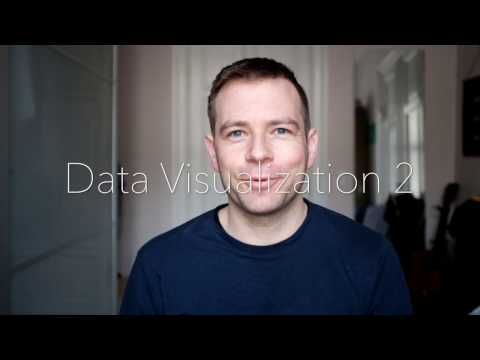

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('zE6Nr8trdrw', width=800, height=450)

> *Exercise 1.1:* Some questions about the video. 
>
> * Mention 10 examples of ways we can encode data.
>   * Possible encodings: position, length, area, shape, color, angle, line weight, line ending, texture, pattern.
> * Are all encodings created equally? Why not? Can you think of an example from the previous lectures?
>   * No, each encoding is good for a specific type of data. For example to show the amount of crime per hour over the SF crime dataset an histogram is the best choice, where the length of the columns is easily perceived by our eyes.
> * Mention 3 encodings that are difficult for the human eye to parse. Can you find an example of a visualization online that uses one of those three?
>   * Angle, area/size or color intensity are more difficult for humans to parse than position and length. Here is an [example](https://clauswilke.com/dataviz/color-pitfalls.html) 
> * Explain in your own words: What is the problem with pie-charts?
>   * It's hard sometimes to define which slice of the pie is larger or smaller. Reading angles in a circle is often harder for our brain than perceiving lengths.

<div class="alert alert-block alert-info">
Try to answer these using your human brain, don't use an LLM.
</div>

## Part 2: Exploratory data visualization, two variables  

I told you how I love the Data Analysis with Open Source Tools book. If you managed to read Chapter 3, which is about visualizing data with two variables, before coming to class today it's great. If you haven't yet, this is the time to do it! 

*Reading*: DAOST Chapter 3 up to *Graphical Analysis and Presentation Graphics* on page 68 in the PDF. **Like Last week, you can find it on Teams**.

And now a few exercises to reflect on the text:

*Exercise 2.1:* Questions from DAOST Chapter 3. 

> * Looking at Fig 3-1, Janert writes "the data itself shows clearly that the amount of random noise in the data is small". What do you think his argument is?
>   * The plot shows a repeating decreasing pattern of consecutive points. This pattern would be a perfect fit for a curve that connects all the points indicating the small amount of noise.
> * Can you think of a real-world example of a multivariate relationship like the one in Fig 3-3 (lower right panel)?
>   * Could describe the effect of a medicine (y) on people of different ages (x), and the multivariate relationship might indicate the sex of the patients.
> * What are the two methods Janert mentions for smoothing noisy data? Can you think of other ones?
>   * He mentions weighted spline and LOESS. Another commonly known method is a moving average. 
> * What are residuals? Why is it a good idea to plot the residuals of your fit?
> * Residuals are what you have left after the subtraction of the fit form the actual datapoints. They are a good indicators to check if the fit is accurate over the span of the dataset. They should be balanced (symmetrically distributed around zero) and should be free of trend.
> * Explain in your own words the point of the smooth tube in figure 3-7.
>   * The smooth tubes are created using the positive and negative residuals after a line has been fit through them. They can be used to define confidence bands for the dataset. 
> * What the h#ll is banking and what part of our visual system does it use to help us see patterns? What are potential problems with banking?
>   * Banking is the modification of the aspect ration of the plot to make the curves in the plot appear with a slope of circa 45 degrees. As humans we have a great affinity for proportions of roughly 4 by 3. Potential problems that could arise with banking are the too much shrinking which makes lose too much details.  
> * Summarize the discussion of Graphical Analysis and Presentation Graphics on pp. 68-69 in your own words.
>   * Graphical analysis is exploratory, meaning the you should use quick, iterative, unpolished plots to discover patterns and form questions. Presentation graphics are final, polished visuals meant to clearly communicate already-understood results. Presentation can include more colors, zooms and using only a subset of the data.

<div class="alert alert-block alert-info">
Read the text and answer the questions to make sure you get it. No need for LLMs here
</div>

Ok. Let's briefly talk about logarithms and logarithmic plots (if you take my networks class in the fall semester you'll se lots of loglog plots since they're important for understanding a key property of networks).

*Exercise 2.2*: Logarithms and logarithmic plots. 

> * First, a couple of questions:
>    * What kind of relationships will a semi-log plot help you discover? <font color=gray>First think, use your brain to answer, then it's OK to get further inspiration from your LLM. The same goes for the next little question.</font>
>       * A semi-log plot will help me discover exponential multiplicative relationships. Useful for example in constant relative-change rates scenario where y displays many orders of magnitude.
>    * What kind of functions will loglog plots help you see?
>       * Log log plots are more indicated for power law relationships where log(y) vs log(x) is linear. Useful for detecting scaling laws.
> * Second, for your Personal Focus Crimes, create a version of "Distribution of crime occurences aggregated over all time" from Week 1's Exercise 3.2, where you display the crime count values on log-scale. Comment on what the plot looks like. Do any new insights arise?
>   * The log plot compared to the normal one shows that a small number of categories account for the majority of incidents. Using the log view makes it clear that frequencies span many orders of magnitude rather than being clustered around a single scale. It's easier to visualize as the majority of the bars are not compressed towards 0 anymore.
> * Third, let's also try a loglog plot. Inspired by [this article](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0183110) I would expect that especially theft could be characterized by a power law distribution also in San Francisco. Let's see if I'm right. <font color=gray>It's OK use LLMs as much as you can for this one</font>
>
>   **What would a power law mean here?** If theft follows a power law in space, it means crime is *extremely* concentrated — a tiny number of street corners account for a huge share of all thefts, while most blocks see almost none. This kind of extreme inequality is the hallmark of power-law distributions, and it has real consequences for how we think about "safe" vs. "dangerous" neighborhoods.
>
>   - *Step 1:* Divide San Francisco into a grid **roughly** $100m \times 100m$. You can, for example use numpy to do this, I would call `np.histogram2d`, and searching the internet, it seems that there are also [ways to do this in pandas](https://stackoverflow.com/questions/39254704/pandas-group-bins-of-data-per-longitude-latitude). The earth isn't flat,so `lat,` `lon` aren't really squares, but it is OK to ignore. 
>       * **Hint 1**. I really mean approximately 100 meters. It can also be 200 meters. Or 80 meters. Or 300.
>       * **Hint 2**. Ignore outliers. We only want points that are on the SF peninsula
>       * **Hint 3**. If you want help, plus see how this is done with all the bells and whistles, we've made a little example of how you can do the binning. Get it [here](https://github.com/suneman/socialdata2022/blob/main/lectures/Week5_binning.ipynb).
>       * **Hint 4**. Ask your LLM.
>   - *Step 2:* Count the number of thefts occurring within each grid-square (use all data for all time).
>   - *Step 3:* Tally the counts. Count the number of squares with $k=0$ thefts. We call this $N(0)$. Next, count the number of grids with one crime to get $N(k=1)$. Keep going like this all the way up to $k=C_{max}$, where $C_{max}$ is the highest count of crimes you find in any grid space. 
>     * *Extra tip*: If you want all the details on binning for loglog axes, you can check out [Lecture 2, Part 3](https://github.com/SocialComplexityLab/socialgraphs2021/blob/main/lectures/Week2.ipynb) in my social graphs course.
>   - *Step 4:* Plot the distribution of $k+1$ vs $N(k)$ on linear axes.
>   - *Step 5:* Plot the distribution of $k+1$ vs $N(k)$ on loglog axes.
>   - *Step 6:* Answer the question. Was it correct of me to assume that there is a power-law distribution of theft?
>       * Yes, it was correct. The linear scale plot is extremely skewed while the log log plot almost falls on a straight line ($R^2=0.82$) with a negative slope (-1.13) confirming the assumption.
>   - *Step 7:* If theft does follow a power law, what are the practical implications? What does this extreme spatial concentration mean for policing, for city planning, and for the people who live in those hotspots? Does the "average" crime rate for a neighborhood even make sense as a statistic when the distribution looks like this?
>       * Following a power law distribution means that the "average" grid-square crime rate is very little and only a few hotspots dominate the total while most blocks see almost no crimes. Policing based on neighborhood averages would flood low-crime areas and under-resource true hotspots that would need more of those police patrols.
<div class="alert alert-block alert-info">
LLM notes are in gray in the text. The final question (Step 7) should be your own thinking.
</div>

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import re
from itertools import combinations

In [3]:
df = pd.read_csv(os.path.join(os.getcwd(), '..', 'files', 'Merged_Police_Incidents_2003_to_Present.csv'))

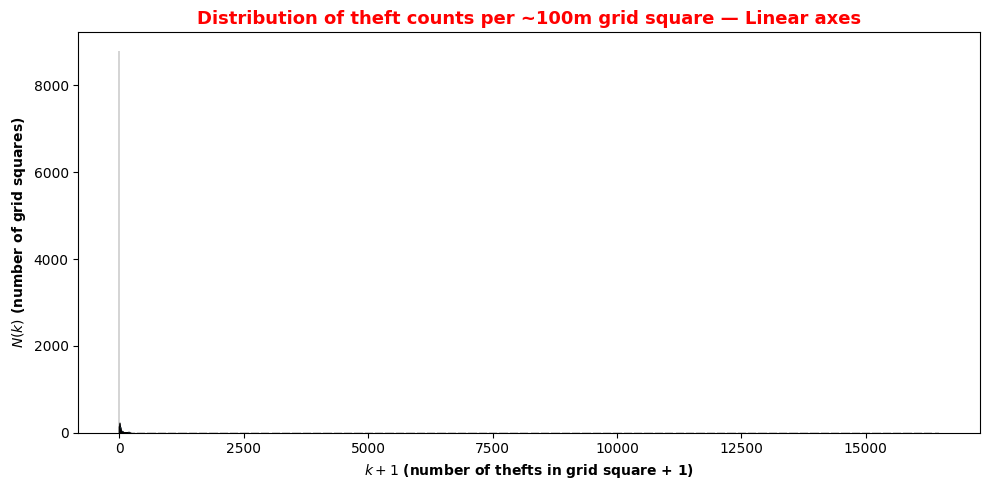

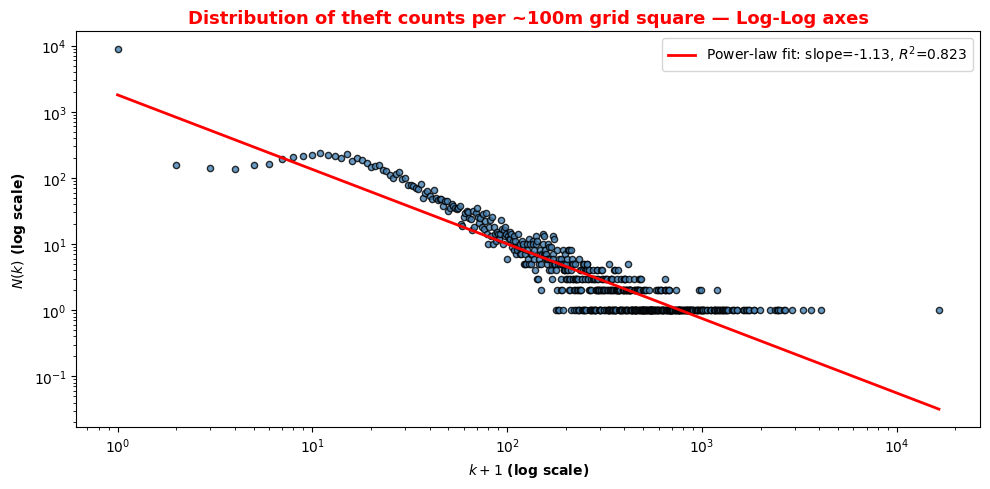

Total grid squares: 17272
Grid squares with 0 thefts: 8783
Max thefts in a single square: 16471


In [4]:
def parse_point(point_str):
    if pd.isna(point_str):
        return np.nan, np.nan
    match = re.match(r'POINT \(([-\d.]+) ([-\d.]+)\)', str(point_str))
    if match:
        return float(match.group(1)), float(match.group(2))
    return np.nan, np.nan

# 1 Filter theft data and extract coordinates
theft_mask = (
    df["Mapped Category"].eq("larceny theft")
    & df["Point"].notna()
)
coords = df.loc[theft_mask, "Point"].apply(parse_point)
lons = np.array([c[0] for c in coords])
lats = np.array([c[1] for c in coords])
# keep only SF peninsula bounds
sf_mask = (
    (lats > 37.70) & (lats < 37.84) &
    (lons > -122.52) & (lons < -122.35)
)
lats_sf = lats[sf_mask]
lons_sf = lons[sf_mask]

# ~100m in degrees: 1 deg lat ≈ 111km, 1 deg lon ≈ 85km at SF latitude
lat_bin_size = 100 / 111000   # ~0.0009 degrees
lon_bin_size = 100 / 85000    # ~0.00118 degrees
lat_bins = np.arange(lats_sf.min(), lats_sf.max() + lat_bin_size, lat_bin_size)
lon_bins = np.arange(lons_sf.min(), lons_sf.max() + lon_bin_size, lon_bin_size)

# 2 Count thefts per grid square
counts_2d, _, _ = np.histogram2d(lats_sf, lons_sf, bins=[lat_bins, lon_bins])
counts_flat = counts_2d.flatten().astype(int)

# 3 Tally N(k)
c_max = counts_flat.max()
k_vals = np.arange(0, c_max + 1)
N_k = np.array([(counts_flat == k).sum() for k in k_vals])
# use k+1 on x-axis (so k=0 doesn't vanish on log scale)
x = k_vals + 1
y = N_k

# 4 Linear axes plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x, y, width=0.8, color="steelblue", edgecolor="black", linewidth=0.3, alpha=0.8)
ax.set_xlabel("$k+1$ (number of thefts in grid square + 1)", fontweight="bold")
ax.set_ylabel("$N(k)$ (number of grid squares)", fontweight="bold")
ax.set_title("Distribution of theft counts per ~100m grid square — Linear axes",
             fontweight="bold", fontsize=13, color="red")
plt.tight_layout()
plt.show()

# 5 Log-log axes plot
pos_mask = y > 0
x_pos = x[pos_mask]
y_pos = y[pos_mask]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x_pos, y_pos, color="steelblue", edgecolor="black", s=20, alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$k+1$ (log scale)", fontweight="bold")
ax.set_ylabel("$N(k)$ (log scale)", fontweight="bold")
ax.set_title("Distribution of theft counts per ~100m grid square — Log-Log axes",
             fontweight="bold", fontsize=13, color="red")

# fit a line in log-log space to check for power law
log_x = np.log10(x_pos)
log_y = np.log10(y_pos)
from scipy import stats
slope, intercept, r, p, se = stats.linregress(log_x, log_y)
x_fit = np.linspace(x_pos.min(), x_pos.max(), 300)
y_fit = 10**(intercept) * x_fit**slope
ax.plot(x_fit, y_fit, color="red", lw=2,
        label=f"Power-law fit: slope={slope:.2f}, $R^2$={r**2:.3f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Total grid squares: {len(counts_flat)}")
print(f"Grid squares with 0 thefts: {(counts_flat == 0).sum()}")
print(f"Max thefts in a single square: {c_max}")

## Part 3: Linear Regression

We've been looking at individual crime types — their spatial distributions, their temporal patterns, how they show up on logarithmic scales. Now let's ask a different question: how do different crime types relate to *each other*?

Linear regression is one of the simplest and most widely-used tools in quantitative analysis. It's also the conceptual foundation for understanding more complex models — if you understand what a linear fit can and can't tell you, you're well-equipped to reason about fancier techniques later. Here, we'll use it to compare the weekly rhythms of your Personal Focus Crimes and find out which pairs march to the same beat — and which ones are completely out of sync.

> *Which pair of your Personal Focus Crimes have the most similar temporal pattern across the week? (And which pair is most dissimilar).*
>   * The most similar pattern is Embezzlement vs Fraud, the most dissimilar is perhaps Missing person vs Prostitution.

One way to answer this question is to plot the activity for all pairs of crime types as a scatter plot per pair. One crime type on each axis, where each point in the scatter corresponds to an hour of the week, and the number of crimes of crime-type 1 is on the $x$-axis and the number of crimes of crime-type 2 is on the $y$-axis. (So there will be 168 points in each scatterplot.)

For this exercise, **select 9 of your Personal Focus Crimes** (from Week 2). If you have fewer than 9, use all of them and come up with a reasonable grid. With 9 crimes, you get $\binom{9}{2} = 36$ pairwise comparisons. 

*Exercise 3.1:* Create the 36 scatterplots.
> * Display the plots in a $6$ by $6$ subplot matrix. You can use matplotlib's `subplot` to organize those plots. With $6$ across and $6$ down, you should be able to squeeze them all onto a single [a4](https://en.wikipedia.org/wiki/ISO_216#A_series) page.
>     * Make sure to label each one with the two crime-types you're comparing so we can easily inspect visually.
>     * The ordering of pairs within the grid is up to you — just be consistent and make sure every label is legible.
>     * Make sure that you squeeze the subplots closely together so each plot can be as big as possible. 
> * Just inspecting this matrix, which crime-types look correlated and which ones look like they're very different?
>   * Crimes that look correlated are: Fraud vs Missing Person, Embezzlement vs Fraud and Assault vs Burglary. Crimes that look very different are: Arson vs Embezzlement, Arson vs Prostitution, Liquor Laws vs Missing Person and Missing person vs Prostitution. 
> * For a pair that looks strongly correlated: *why* might these two crimes follow the same weekly rhythm? What shared factors could drive both?
>   * Taking for example Embezzlement vs Fraud both are financial/paperwork-heavy crimes that likely occur or are discovered during the standard work week and times.
> * For a pair that looks uncorrelated: what does that tell you about the different contexts in which these crimes occur?
>   * Taking for example Missing Person and Prostitution, these two crimes are reported at completely different times of the day which explains the lack of correlation. The reports of missing person usually occur in the morning when family or friends notice the person is missing while prostitution is generally a night activity.

<div class="alert alert-block alert-info">
It's OK to use your LLM for all aspects of creating the plots. The interpretation should be your own thinking.
</div>

In [5]:
FOCUS_CRIMES = ["assault", "arson", "burglary", "embezzlement", "fraud", "gambling", 
                      "liquor laws", "missing person", "non-criminal", 
                      "prostitution", "recovered vehicle", "robbery", "stolen property", 
                      "suicide", "suspicious occ", "disorderly conduct", "motor vehicle theft", 
                      "larceny theft", "warrant", "forgery and counterfeiting"]
FOCUS_CRIMES_MINUS_NONCRIMINAL = [crime for crime in FOCUS_CRIMES if crime != "non-criminal"]
NINE_FOCUS_CRIMES_MINUS_NONCRIMINAL = FOCUS_CRIMES_MINUS_NONCRIMINAL[:9]

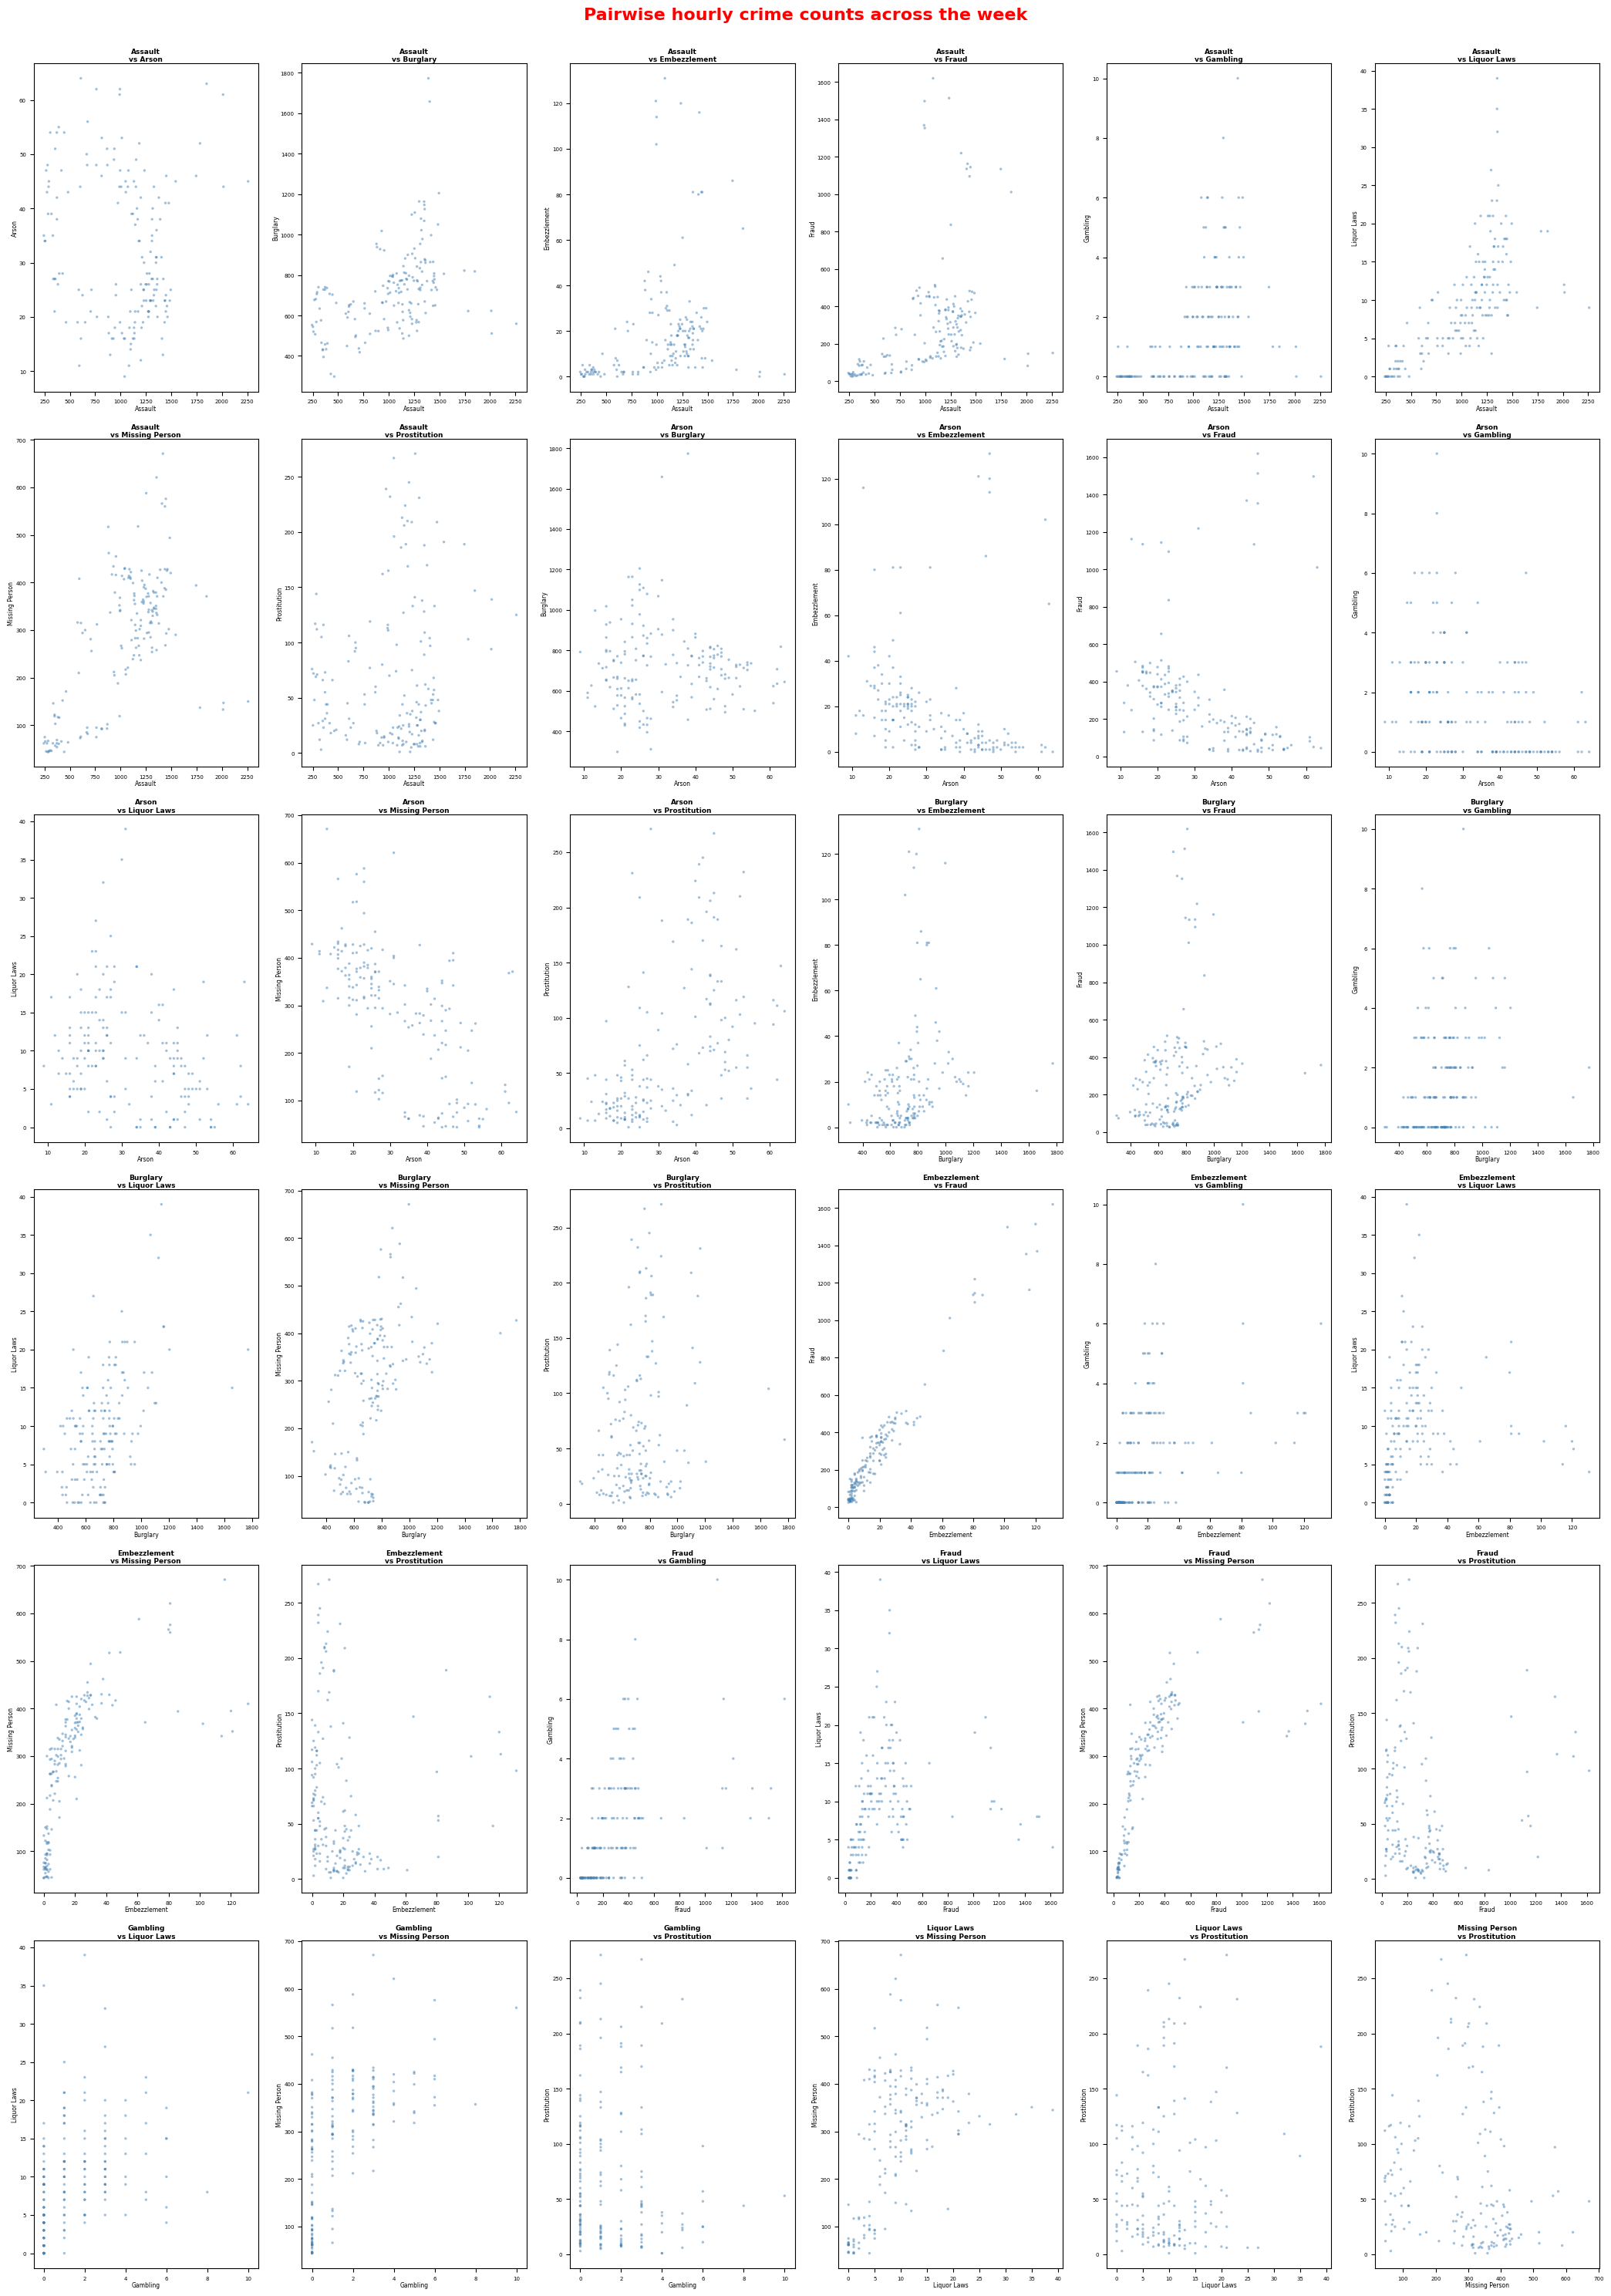

In [6]:
# hourly-per-week counts 
# hour of week: 0 = Monday 00:00, 167 = Sunday 23:00
df_focus9 = df[df["Mapped Category"].isin(NINE_FOCUS_CRIMES_MINUS_NONCRIMINAL)].copy()
df_focus9["Incident Datetime"] = pd.to_datetime(df_focus9["Incident Datetime"], errors="coerce")
df_focus9 = df_focus9.dropna(subset=["Incident Datetime"])
df_focus9["hour_of_week"] = (
    df_focus9["Incident Datetime"].dt.dayofweek * 24
    + df_focus9["Incident Datetime"].dt.hour
)

# pivot: rows = hour_of_week (0-167), columns = crime type, values = count
hourly = (
    df_focus9.groupby(["hour_of_week", "Mapped Category"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=NINE_FOCUS_CRIMES_MINUS_NONCRIMINAL, fill_value=0)
    .reindex(index=range(168), fill_value=0)  # ensure all 168 hours present
)

# Build list of all 36 unique pairs
pairs = list(combinations(NINE_FOCUS_CRIMES_MINUS_NONCRIMINAL, 2))  # 36 pairs
ncols, nrows = 6, 6
fig, axes = plt.subplots(nrows, ncols, figsize=(21.0, 29.7))
fig.suptitle("Pairwise hourly crime counts across the week",
             fontsize=16, fontweight="bold", color="red", y=1.001)

for idx, ax in enumerate(axes.flatten()):
    if idx >= len(pairs):
        ax.set_visible(False)
        continue

    crime_x, crime_y = pairs[idx]
    x_vals = hourly[crime_x].values
    y_vals = hourly[crime_y].values

    ax.scatter(x_vals, y_vals, s=6, alpha=0.5, color="steelblue", edgecolors="none")

    ax.set_title(f"{crime_x.title()}\nvs {crime_y.title()}",
                 fontsize=6.5, fontweight="bold", pad=2)
    ax.tick_params(axis="both", labelsize=5)
    ax.set_xlabel(crime_x.title(), fontsize=5.5, labelpad=1)
    ax.set_ylabel(crime_y.title(), fontsize=5.5, labelpad=1)

plt.subplots_adjust(hspace=0.55, wspace=0.45)
plt.tight_layout()
plt.show()

---

Next it's time for the linear regression. Janert writes about this on page 63-66. 

There is a closed-form solution for linear regression. If you want to find the best straight line $y = ax + b$ fit to a set of $N$ points $\{(x_1,y_1), (x_2,y_2), \ldots (x_N,y_N)\}$, the value of $b$ is

$$
\tag{1}
b = \langle y \rangle - a \langle x \rangle,
$$

where $\langle x \rangle = (1/N)\sum_i x_i$ is the mean value of the $x_i$ and $\langle y \rangle = (1/N)\sum_i y_i$ is the mean value of the $y_i$. 

And the value for the slope $a$ is 

$$
\tag{2}
a = \frac{\sum_{i=1}^N \left( x_iy_i \right) - N \langle x\rangle\langle y\rangle }{\sum_{i=1}^N\left( x_i^2 \right) - N\langle x\rangle^2}.
$$


A few of years ago, I actually derived the whole thing, it's not hard, but it takes up a lot of space, so I've taken it out of the notebook. But if you'd like to take a look (it's a fun and instructive exercise), you can find it **[here](https://github.com/suneman/socialdata2021/blob/main/lectures/LinearRegressionDerived.ipynb)**. 

We are going to focus on the fit for now, but keep in mind what we have learnt so far about the purpose of linear regression! 

*Exercise 3.2:* Linear regression. 

> * Using Equation 1 and 2 above, calculate the slopes for $a$ and $b$ in each case and add them to the plot. (You are free to compare the results with ones obtained using a package like `sklearn` to check that everything is working as expected.) <font color=gray>See if you can do this by yourself without LLM help</font>.
> * You can add even more information to this plot by coloring each point according to its hour of the week. So create a gradient going from one color to another, and color each point according to the gradient. (So let's say your two colors are red and blue, then the Sunday, midnight to 1am bin will be red and the following Sunday, 11pm - midnight bin will be blue). <font color=gray>It's OK use full LLM help here</font>
> * Do any patterns stand out as you inspect the plot? Mention one or two that catch your eye -- it may be both because the sequences are similar or because they are different, or something entirely different altogether.
>   * Every plot that involves Gambling crimes tends to have points, relative to the weekend, closer together. This indicates that Gambling is a low-frequency, discrete crime that happens mostly in the weekends.

<div class="alert alert-block alert-info">
See LLM comments in gray.
</div>

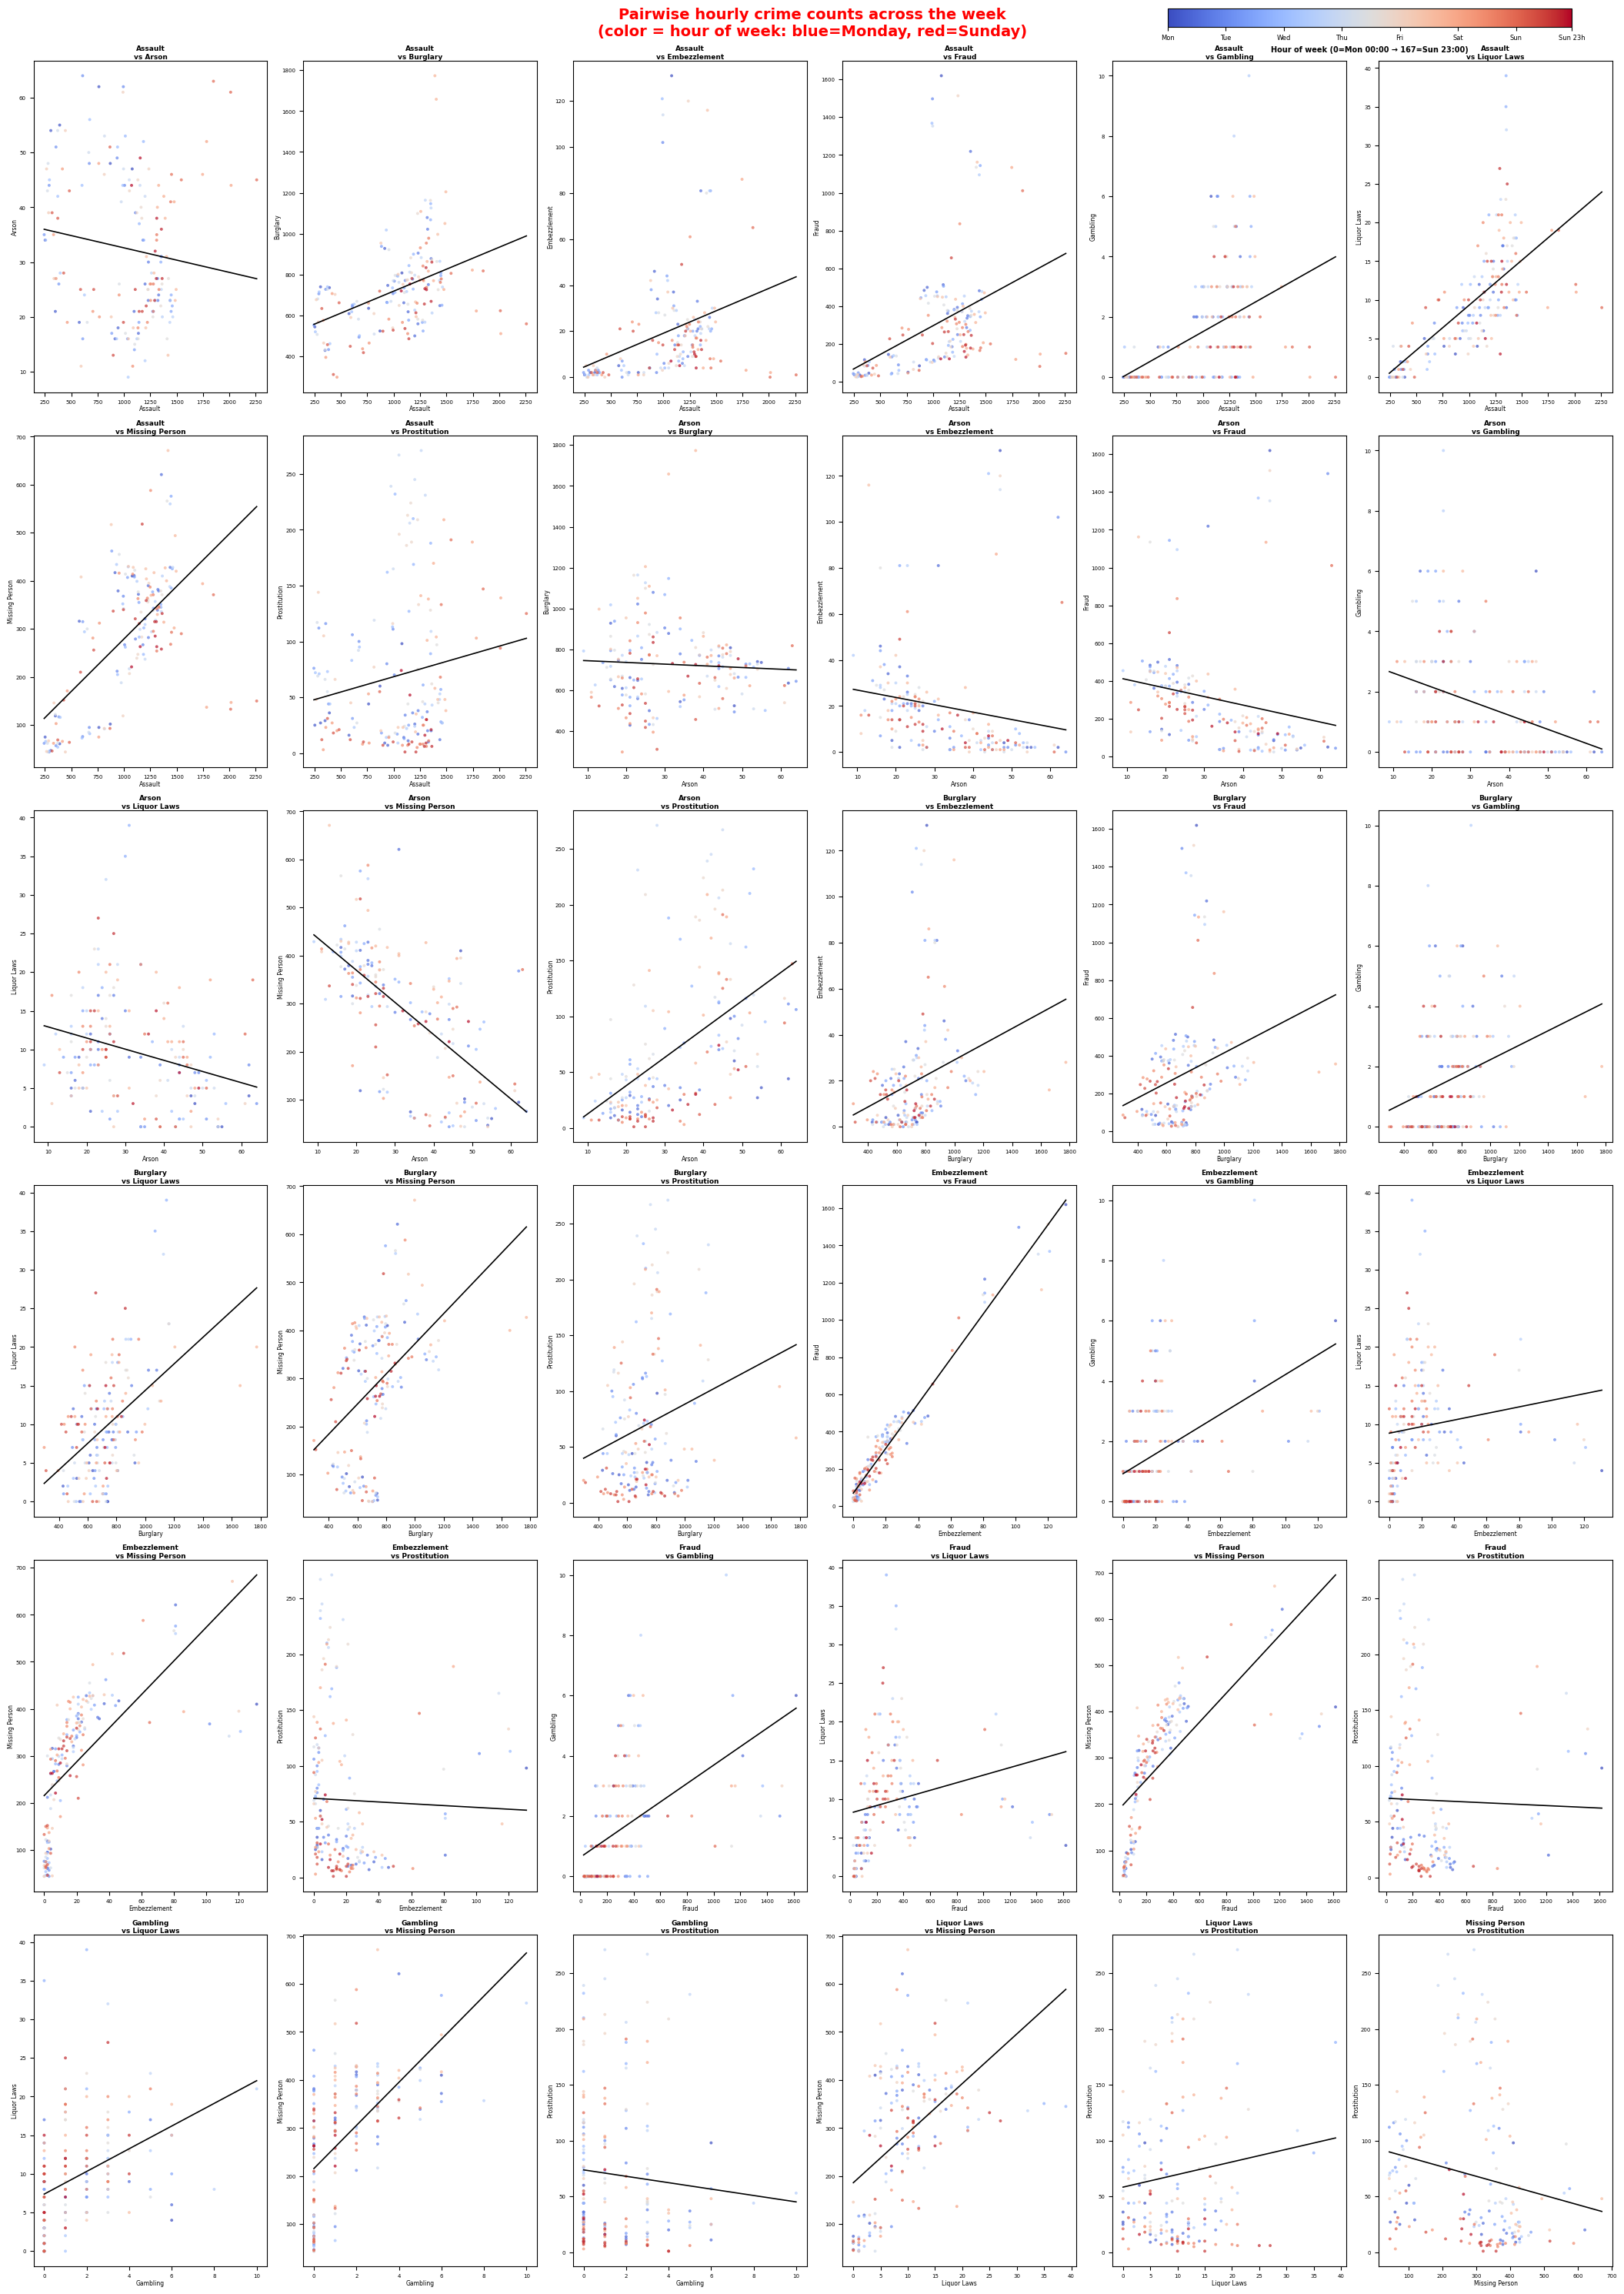

In [7]:
def linreg_scratch(x, y):
    N = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    a = (np.sum(x * y) - N * x_mean * y_mean) / (np.sum(x ** 2) - N * x_mean ** 2)
    b = y_mean - a * x_mean
    return a, b

# Color gradient: hour 0 (Monday 00:00) = blue, hour 167 (Sunday 23:00) = red
cmap = plt.cm.coolwarm
colors = cmap(np.linspace(0, 1, 168))  # one color per hour of week
pairs = list(combinations(NINE_FOCUS_CRIMES_MINUS_NONCRIMINAL, 2))
ncols, nrows = 6, 6
fig, axes = plt.subplots(nrows, ncols, figsize=(21.0, 29.7), constrained_layout=True)
fig.suptitle("Pairwise hourly crime counts across the week\n(color = hour of week: blue=Monday, red=Sunday)",
             fontsize=14, fontweight="bold", color="red")

for idx, ax in enumerate(axes.flatten()):
    if idx >= len(pairs):
        ax.set_visible(False)
        continue

    crime_x, crime_y = pairs[idx]
    x_vals = hourly[crime_x].values.astype(float)
    y_vals = hourly[crime_y].values.astype(float)

    # scatter with hour-of-week color
    ax.scatter(x_vals, y_vals, c=colors, s=8, alpha=0.7, edgecolors="none", zorder=2)

    # linear regression from scratch
    a, b = linreg_scratch(x_vals, y_vals)
    x_fit = np.array([x_vals.min(), x_vals.max()])
    ax.plot(x_fit, a * x_fit + b, color="black", lw=1.2, zorder=3)

    ax.set_title(f"{crime_x.title()}\nvs {crime_y.title()}",
                 fontsize=6.5, fontweight="bold", pad=2)
    ax.tick_params(axis="both", labelsize=5)
    ax.set_xlabel(crime_x.title(), fontsize=5.5, labelpad=1)
    ax.set_ylabel(crime_y.title(), fontsize=5.5, labelpad=1)

cbar_ax = fig.add_axes([0.72, 0.99, 0.25, 0.008])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=167))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Hour of week (0=Mon 00:00 → 167=Sun 23:00)", fontsize=7, fontweight="bold")
cbar.set_ticks([0, 24, 48, 72, 96, 120, 144, 167])
cbar.set_ticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun", "Sun 23h"], fontsize=6)

plt.show()

---

But the question we started with was "Which pair of Personal Focus Crimes have the most similar temporal pattern across the week?". We haven't really answered that yet. So let's calculate one last thing: $R^2$. 

Basically $R^2$ is a measure of how good a linear fit is. You can [read about $R^2$ on wikipedia](https://en.wikipedia.org/wiki/Coefficient_of_determination). 

*Exercise 3.3:* Goodness of fit as a measure of correlation. 
> * Write a little function to calculate $R^2$ alongside each linear fit. (Again you can compare it with a package to check that it works, e.g. the one provided by the function `score()` in `sklearn`.) <font color=gray>Try this without the help of an LLM.</font>
> * Explain the connection between $R^2$ and the [Pearson correlation coefficient](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient). <font color=gray>Try this without the help of an LLM, at least first. Then you may ask it to see if you got it right.</font>
>   * $R^2$ is the square of the Pearson correlation coefficient $r$. So $R^2=r^2$. The difference between the two metrics is that $R^2$ tells you how much variation of one variable is explained by the other, while $r$ tells you how strongly related are the two variables. $r \in [-1, 1]$ and $R^2 \in [0, 1]$.
> * **According to the fits and associated $R^2$**, which pair of crimes have the **most similar** temporal pattern. Discuss your finding: Does it make sense? Why?/Why not?
>   * The one with the most similar temporal pattern are Embezzlement vs Fraud. As explained above it makes sense as these crimes are usually done and reported during day and time of work (for offices).
> * According to your fits and associated measure of $R^2$, which pair of crimes have the **most dissimilar** temporal pattern. Discuss your finding: Does it make sense? Why?/Why not? Does it corresponds with your observations from the previous exercise?
>   * The one with the most dissimilar temporal pattern are Fraud vs Prostitution. The argument is similar to above, the Fraud is usually done and reported during work hours while prostitution is a night crime mostly, so it makes sense that these two crimes have pretty dissimilar temporal patterns. 
> * Create a final mega-plot with all 36 scatter plots, fits, and $R^2$ value written as [text](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html) on each plot. In this figure, you should also find a way to visually highlight the two most similar/dissimilar crimes. <font color=gray>Totally fine to use an LLM to help you organize the plot and make it look amazing.</font>
> * **Connecting back to Week 1**: Think about what your most correlated crime pair means in the context of predictive policing. If a system uses patterns from one crime type to allocate resources for another (because they're correlated), what could go wrong? Consider especially what happens if one of the correlated crimes is enforcement-driven (like drug offenses — more police presence leads to more arrests, which looks like "more crime"). How does this relate to the feedback loops discussed in the Richardson et al. reading?
>   * The Embezzlement vs Fraud plot describes the situation of two report driven crimes where a victim needs to file a report. The risk is that if a systems detects a spike in Fraud, and police decides to investigate more and put more resources there, it will naturally uncover more Embezzlement. This is defined as a feedback loop.

<div class="alert alert-block alert-info">
See LLM comments in gray. The final reflection question should be your own thinking — this is where you connect the technical work to the bigger picture from Week 1.
</div>

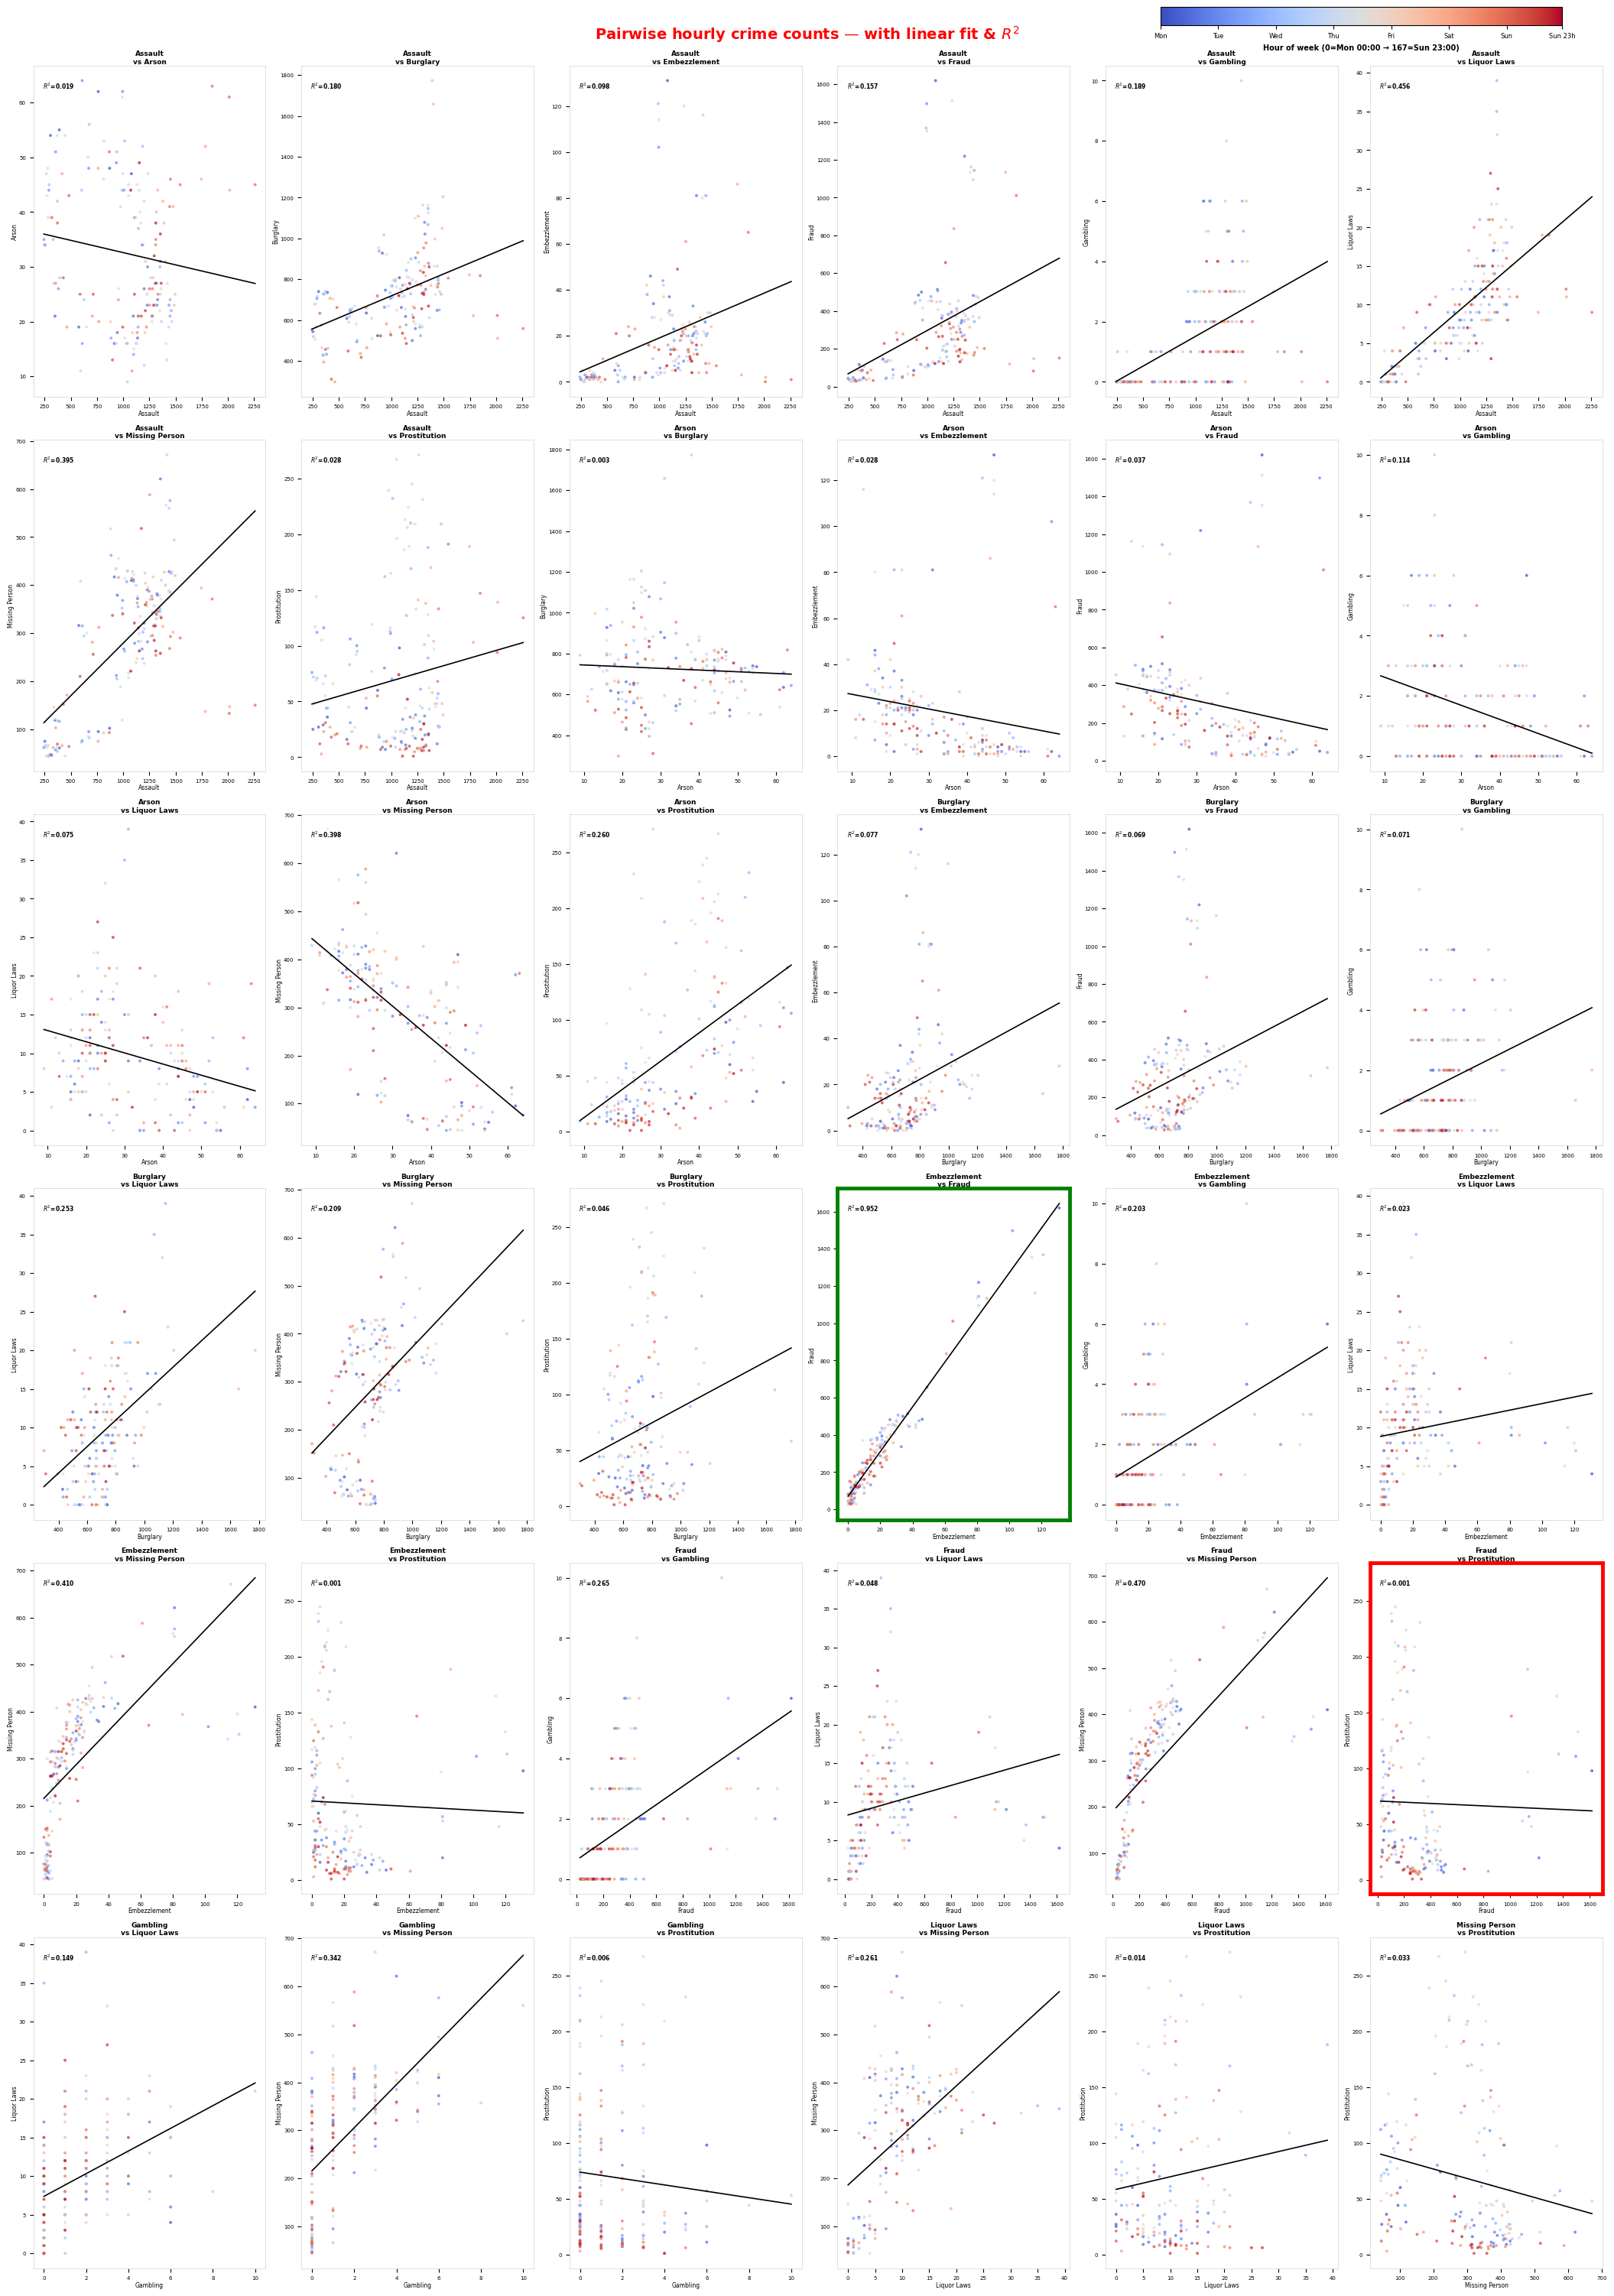

<Figure size 640x480 with 0 Axes>

In [ ]:
def r_squared(x, y, a, b):
    """R² = 1 - SS_res / SS_tot"""
    y_pred = a * x + b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

# Pre-compute R² for all 36 pairs to find best/worst
pairs = list(combinations(NINE_FOCUS_CRIMES_MINUS_NONCRIMINAL, 2))
r2_scores = {}
for crime_x, crime_y in pairs:
    x_vals = hourly[crime_x].values.astype(float)
    y_vals = hourly[crime_y].values.astype(float)
    a, b = linreg_scratch(x_vals, y_vals)
    r2_scores[(crime_x, crime_y)] = r_squared(x_vals, y_vals, a, b)

best_pair  = max(r2_scores, key=r2_scores.get)
worst_pair = min(r2_scores, key=r2_scores.get)
# print(f"Most similar  (highest R²): {best_pair[0].title()} vs {best_pair[1].title()}  →  R²={r2_scores[best_pair]:.3f}")
# print(f"Most dissimilar (lowest R²): {worst_pair[0].title()} vs {worst_pair[1].title()}  →  R²={r2_scores[worst_pair]:.3f}")
cmap   = plt.cm.coolwarm
colors = cmap(np.linspace(0, 1, 168))

ncols, nrows = 6, 6
fig, axes = plt.subplots(nrows, ncols, figsize=(21.0, 29.7), constrained_layout=True)
fig.suptitle("Pairwise hourly crime counts — with linear fit & $R^2$",
             fontsize=14, fontweight="bold", color="red")

for idx, ax in enumerate(axes.flatten()):
    if idx >= len(pairs):
        ax.set_visible(False)
        continue

    crime_x, crime_y = pairs[idx]
    x_vals = hourly[crime_x].values.astype(float)
    y_vals = hourly[crime_y].values.astype(float)
    a, b   = linreg_scratch(x_vals, y_vals)
    r2     = r_squared(x_vals, y_vals, a, b)

    # highlight border for best / worst pair
    pair_key = (crime_x, crime_y)
    if pair_key == best_pair:
        spine_color, spine_lw = "green", 3.5
    elif pair_key == worst_pair:
        spine_color, spine_lw = "red", 3.5
    else:
        spine_color, spine_lw = "lightgray", 0.5

    for spine in ax.spines.values():
        spine.set_edgecolor(spine_color)
        spine.set_linewidth(spine_lw)

    # scatter colored by hour-of-week
    ax.scatter(x_vals, y_vals, c=colors, s=8, alpha=0.7, edgecolors="none", zorder=2)

    # regression line
    x_fit = np.array([x_vals.min(), x_vals.max()])
    ax.plot(x_fit, a * x_fit + b, color="black", lw=1.2, zorder=3)

    # R² text inside plot (top-left corner)
    ax.text(0.04, 0.93, f"$R^2$={r2:.3f}",
            transform=ax.transAxes, fontsize=5.5,
            fontweight="bold", color="black",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))

    ax.set_title(f"{crime_x.title()}\nvs {crime_y.title()}",
                 fontsize=6.5, fontweight="bold", pad=2)
    ax.tick_params(axis="both", labelsize=5)
    ax.set_xlabel(crime_x.title(), fontsize=5.5, labelpad=1)
    ax.set_ylabel(crime_y.title(), fontsize=5.5, labelpad=1)

# colorbar next to title 
cbar_ax = fig.add_axes([0.72, 0.998, 0.25, 0.008])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=167))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Hour of week (0=Mon 00:00 → 167=Sun 23:00)", fontsize=7, fontweight="bold")
cbar.set_ticks([0, 24, 48, 72, 96, 120, 144, 167])
cbar.set_ticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun", "Sun 23h"], fontsize=6)

plt.show()
plt.savefig("yearly_crime_trends.png", dpi=150)

---

## You've Completed Week 4!

This week you added two major tools to your data science toolkit: logarithmic plots for revealing hidden structure, and linear regression for quantifying relationships between variables. You now have:

- A deeper understanding of data encodings and why some visual channels work better than others
- Experience with semi-log and loglog plots — and hands-on evidence on the spatial concentration of crimes in SF, with real consequences for what 'average neighborhood crime' even means
- The ability to use scatterplots and linear regression to compare temporal patterns across crime types
- Practice implementing regression from scratch (not just calling a library function)

**Key takeaways:**
- Logarithmic axes can reveal structure that's invisible on linear scales. Always consider whether your data spans multiple orders of magnitude.
- Power laws are everywhere in social data. When crime concentrates in a tiny number of hotspots, policies built on neighborhood averages can be deeply misleading — or even harmful.
- $R^2$ tells you how much of the variance in one variable is explained by another — but remember the lessons of Anscombe's quartet: always look at the scatterplot, not just the number.
- Crime types that correlate strongly may share underlying drivers (e.g., opportunity, time-of-day patterns). Crime types that don't correlate may respond to very different factors.

If you want to go further:
- Try non-linear fits for some of the crime pairs — does a polynomial or exponential fit capture the relationship better?
- Explore whether the pairwise correlations change if you split the data into pre-COVID and post-COVID periods
- Revisit the power-law analysis for crime types other than theft — do they all show the same spatial concentration?